# From Forecasts to Decisions: Computational Companion

**Systems Realization Laboratory, University of Oklahoma**

In this notebook we implement the procedure reported in the paper and reproduce every
number and figure it contains. Through this procedure, designers connect forecast-informed
quantities, evidence about data credibility and model-form sensitivity, and
stakeholder-defined requirements to a configuration decision. We use the compromise
Decision Support Problem as the formal satisficing construct.

**Research question.** How can designers systematically connect forecast-informed
quantities, evidence about data credibility and model sensitivity, and stakeholder-defined
requirements to support traceable satisficing-based configuration decisions under
uncertainty?

**Contents**

1. Provenance of every input
2. The two mapping decisions: role and confidence
3. How researchers classify credibility and model-form sensitivity
4. The response table and what designers do for each action
5. The demonstration: scope and system model
6. The demand value and its relation to our earlier forecast
7. Stage 1: screening representative configurations
8. Stage 2: searching for a satisfactory configuration
9. Verification and the reduction to screening
10. The demand value and the limit of feasibility
11. A highly sensitive input: the solar capacity factor
12. The traceable record
13. Figures

## 1. Provenance of every input

We take every engineering value from a documented public source and record the value
together with its source, so that a reader can trace each number. Where an authoritative
source does not report a value specific to Iran, we use a documented global representative
value and identify it as such.

In [1]:
import numpy as np, pandas as pd, pulp
import iran_cdsp as M
pd.set_option("display.max_colwidth", 88); pd.set_option("display.width", 200)

pd.DataFrame([(k, v[0], v[1]) for k, v in M.PROVENANCE.items()],
             columns=["Quantity", "Value", "Documented public source"])

,Quantity,Value,Documented public source
0,K_exist.hydro,11.781 GW,"IRENA Renewable Capacity Statistics 2025, Iran, year-end 2024 (renewable hydro, excl..."
1,K_exist.solarpv,0.782 GW,"IRENA Renewable Capacity Statistics 2025, Iran, year-end 2024"
2,K_exist.geothermal,0.0 GW,IRENA Renewable Capacity Statistics 2025 (no Iran geothermal entry; greenfield)
3,K_exist.biofuel,0.022 GW,"IRENA Renewable Capacity Statistics 2025, Iran, year-end 2024 (biogas)"
4,K_exist.gas_fixed,77.0 GW,"Iran Thermal Power Plants Holding via Tehran Times 2024 (combined cycle 35.663, gas ..."
5,CF.hydro,0.18,Iran drought-adjusted. IRENA global hydro capacity factor is 0.535; Iran 2023 actual...
6,CF.solarpv,0.162,"IRENA Renewable Power Generation Costs in 2023, global weighted average, utility-sca..."
7,CF.geothermal,0.821,"IRENA Renewable Power Generation Costs in 2023, global weighted average, geothermal"
8,CF.biofuel,0.719,"IRENA Renewable Power Generation Costs in 2023, global weighted average, bioenergy"
9,CF.gas_fixed,0.524,Calibrated so that existing thermal generation reproduces the IRENA-reported 2023 Ir...


## 2. The two mapping decisions

Designers make two decisions when a forecasted quantity enters the decision problem, and
we keep them separate.

**First decision, the role.** Designers determine what the quantity *is* in the problem:
a fixed input, a decision variable, a bound, a non-negotiable requirement, a desired
target, or a scenario. Designers determine the role by the function of the quantity in the
problem, not by how well researchers know it.

**Second decision, the confidence.** Designers determine how to *use the value*, based on
the credibility of the supporting data and the sensitivity of the forecast to defensible
modeling choices.

Keeping these separate prevents a designer from treating a well-measured quantity as a
non-negotiable requirement merely because researchers measured it well. Meeting demand is
a rigid requirement regardless of confidence; the demand *value* is uncertain, so we vary
it across the reported interval.

In [2]:
pd.DataFrame([
    ["Demand coverage", "Non-negotiable requirement", "Rigid constraint", "Role"],
    ["2030 demand value", "Uncertain level of that requirement", "Constraint level, varied across the interval", "Confidence"],
    ["New capacity per technology", "Quantity the designer selects", "Decision variable", "Role"],
    ["2030 build limit", "Limit on what designers can build", "Bound on the decision variables", "Role"],
    ["Renewable share", "Desired target", "Goal with deviation variables", "Role"],
    ["Emissions", "Desired target", "Goal with deviation variables", "Role"],
    ["Cost", "Desired target", "Goal with deviation variables", "Role"],
    ["Solar capacity factor", "Highly sensitive forecast input", "Coefficient, tested across model forms", "Confidence"],
], columns=["Quantity", "Role in the decision", "Representation in the compromise DSP", "Determined by"])

,Quantity,Role in the decision,Representation in the compromise DSP,Determined by
0,Demand coverage,Non-negotiable requirement,Rigid constraint,Role
1,2030 demand value,Uncertain level of that requirement,"Constraint level, varied across the interval",Confidence
2,New capacity per technology,Quantity the designer selects,Decision variable,Role
3,2030 build limit,Limit on what designers can build,Bound on the decision variables,Role
4,Renewable share,Desired target,Goal with deviation variables,Role
5,Emissions,Desired target,Goal with deviation variables,Role
6,Cost,Desired target,Goal with deviation variables,Role
7,Solar capacity factor,Highly sensitive forecast input,"Coefficient, tested across model forms",Confidence


## 3. How researchers classify credibility and model-form sensitivity

For other researchers to apply the response table consistently, the two classifications
require stated criteria.

**Data credibility.** Researchers consider the data source and its authority, the
completeness of the observations, the consistency of the records, the temporal coverage
relative to the planning horizon, the directness of measurement, the transformations
required, and the dependence on proxy or derived information.

**Model-form sensitivity.** Researchers fit a retained model, a defensible alternate
model, and a conservative model to the same data, compare the values they yield for the
planning year, and consider both the spread among those values and whether differences of
that size materially change the configuration evaluation.

In [3]:
credibility = pd.DataFrame([
    ["High", "An authoritative source reports the quantity directly for the system under study; records complete and consistent; few transformations; no proxy dependence.", "Existing installed capacity"],
    ["Medium", "A recognized source reports it, but for a broader population, or with gaps, shorter coverage, or required transformations; partial proxy dependence.", "Technology capacity factors and costs (global averages)"],
    ["Low", "No authoritative source reports it for the system under study; inferred from sparse, inconsistent, or indirect observations, or from an uncertain proxy.", "Not used as a decision input here"],
], columns=["Level", "Conditions that place a quantity at this level", "Example"])

sensitivity = pd.DataFrame([
    ["Low", "Retained, alternate, and conservative models agree closely; differences do not change which configurations satisfy the requirements.", "Existing installed capacity (observed, not forecast)"],
    ["Moderate", "Models differ appreciably, but designers reach configurations satisfying the same requirements across that range.", "2030 demand"],
    ["High", "Models differ enough that designers would reach a materially different configuration, or acceptance changes across forms.", "Solar capacity factor"],
], columns=["Level", "Conditions that place a quantity at this level", "Example"])

display(credibility); display(sensitivity)

,Level,Conditions that place a quantity at this level,Example
0,High,An authoritative source reports the quantity directly for the system under study; re...,Existing installed capacity
1,Medium,"A recognized source reports it, but for a broader population, or with gaps, shorter ...",Technology capacity factors and costs (global averages)
2,Low,"No authoritative source reports it for the system under study; inferred from sparse,...",Not used as a decision input here


,Level,Conditions that place a quantity at this level,Example
0,Low,"Retained, alternate, and conservative models agree closely; differences do not chang...","Existing installed capacity (observed, not forecast)"
1,Moderate,"Models differ appreciably, but designers reach configurations satisfying the same re...",2030 demand
2,High,Models differ enough that designers would reach a materially different configuration...,Solar capacity factor


## 4. The response table and what designers do for each action

Designers use the response table to determine how to use the value of a quantity, entering
by the credibility level and the sensitivity level. Each cell names an action, and each
action has an operational description so that other researchers can apply it consistently.

In [4]:
response = pd.DataFrame(
    [["Use as reported", "Use, and record the sensitivity", "Use, and test across model forms"],
     ["Use with a stated caution", "Widen the value", "Widen the value and test across model forms"],
     ["Qualify the value", "Qualify and widen the value", "Flag the value; test across model forms or defer"]],
    index=["High data credibility", "Medium data credibility", "Low data credibility"],
    columns=["Low model-form sensitivity", "Moderate model-form sensitivity", "High model-form sensitivity"])
display(response)

actions = pd.DataFrame([
    ["Use as reported", "Enter the reported value without adjustment; record the source."],
    ["Use, and record the sensitivity", "Enter the reported value; record the spread across model forms so a reviewer sees the exposure."],
    ["Use with a stated caution", "Enter the value; state the specific limitation of the source in the text."],
    ["Widen the value", "Replace the single value with an interval: the combined range across retained, alternate, and conservative results, extended to the reported uncertainty interval where available. Otherwise apply and state a documented adjustment rule."],
    ["Qualify the value", "Use the value only in a role where an error does not invalidate the decision, that is, as a target rather than a rigid constraint."],
    ["Test across model forms", "Solve once per defensible model form and compare. Sufficient when the configurations satisfy the same requirements across all forms; insufficient when acceptance changes across forms, in which case designers need additional information."],
    ["Flag the value; defer", "Record as unresolved, exclude from the requirements determining acceptance, and state what evidence would admit it."],
], columns=["Action", "What designers do"])
display(actions)

,Low model-form sensitivity,Moderate model-form sensitivity,High model-form sensitivity
High data credibility,Use as reported,"Use, and record the sensitivity","Use, and test across model forms"
Medium data credibility,Use with a stated caution,Widen the value,Widen the value and test across model forms
Low data credibility,Qualify the value,Qualify and widen the value,Flag the value; test across model forms or defer


,Action,What designers do
0,Use as reported,Enter the reported value without adjustment; record the source.
1,"Use, and record the sensitivity",Enter the reported value; record the spread across model forms so a reviewer sees th...
2,Use with a stated caution,Enter the value; state the specific limitation of the source in the text.
3,Widen the value,"Replace the single value with an interval: the combined range across retained, alter..."
4,Qualify the value,"Use the value only in a role where an error does not invalidate the decision, that i..."
5,Test across model forms,Solve once per defensible model form and compare. Sufficient when the configurations...
6,Flag the value; defer,"Record as unresolved, exclude from the requirements determining acceptance, and stat..."


## 5. The demonstration: scope and system model

We instantiate the procedure on national energy planning for Iran in 2030. We model an
annual energy balance and capacity-planning problem. We do not represent hourly dispatch,
transmission, storage, or regional differences.

Added renewable generation displaces gas rather than adding to it, so we compute gas
generation as the residual needed to meet demand after renewables, limited by the fixed
fleet's maximum output. Through this treatment, emissions and cost respond to the
decision.

In [5]:
print(f"Renewable generation, existing fleet : {M.renewable_gen_add({}):8.2f} TWh/yr")
print(f"Gas fleet maximum output             : {M.gas_max_generation():8.2f} TWh/yr")
print(f"Renewable maximum at 2030 limits     : {M.max_renewable_generation():8.2f} TWh/yr")
print(f"System maximum generation, 2030      : {M.max_system_generation():8.2f} TWh/yr")
print(f"Central 2030 demand projection       : {M.DEMAND['point']:8.2f} TWh/yr")

Renewable generation, existing fleet :    19.82 TWh/yr
Gas fleet maximum output             :   353.45 TWh/yr
Renewable maximum at 2030 limits     :    60.91 TWh/yr
System maximum generation, 2030      :   414.36 TWh/yr
Central 2030 demand projection       :   389.76 TWh/yr


## 6. The demand value and its relation to our earlier forecast

In the earlier forecasting work of this research programme, researchers produced a 2030
Iran demand value of approximately 377.1 TWh from the project dataset. For this
demonstration we selected the externally reported projection of approximately 389.8 TWh,
because researchers derived it in a documented Iran-specific study.

We report both values, use 389.8 TWh as the central planning value, and retain 377.1 TWh
as a comparison and plausibility check.

In [6]:
ext, earl = M.DEMAND["point"], M.DEMAND["earlier_forecast"]
diff = ext - earl
print(f"External Iran-specific projection : {ext:.2f} TWh/yr")
print(f"Our earlier forecast              : {earl:.1f} TWh/yr")
print(f"Difference                        : {diff:.2f} TWh/yr = {diff/earl*100:.1f}% of the earlier value")
print(f"Reported interval of the external study: [{M.DEMAND['ci_low']:.2f}, {M.DEMAND['ci_high']:.2f}] TWh/yr")
print(f"Our earlier forecast lies inside that interval: {M.DEMAND['ci_low'] <= earl <= M.DEMAND['ci_high']}")

External Iran-specific projection : 389.76 TWh/yr
Our earlier forecast              : 377.1 TWh/yr
Difference                        : 12.66 TWh/yr = 3.4% of the earlier value
Reported interval of the external study: [363.64, 408.50] TWh/yr
Our earlier forecast lies inside that interval: True


## 7. Stage 1: screening representative configurations

We construct four named configurations by stated rules and screen each against the
requirements. We reject a configuration that fails the critical demand requirement, flag
one that fails an important requirement, and accept it otherwise.

In [7]:
D = M.demand_design_value("point")
s1 = pd.DataFrame([M.screen_config(n, k, D) for n, k in M.NAMED_CONFIGS.items()])
view = s1[["config", "supply_TWh", "renewable_share", "emissions_Mt", "cost_bnUSD", "status"]].copy()
view["renewable_share"] = (view["renewable_share"] * 100).round(1)
view[["supply_TWh", "emissions_Mt", "cost_bnUSD"]] = view[["supply_TWh", "emissions_Mt", "cost_bnUSD"]].round(2)
view.columns = ["Configuration", "Generation (TWh/yr)", "Renewable share (%)",
                "Emissions (Mt CO2/yr)", "Cost (bn USD/yr)", "Outcome"]
display(view)

for r in s1.itertuples():
    why = []
    if r.critical_fail:  why.append("fails critical: " + ", ".join(r.critical_fail))
    if r.important_fail: why.append("misses important: " + ", ".join(r.important_fail))
    if r.desirable_fail: why.append("misses desirable: " + ", ".join(r.desirable_fail))
    print(f"  {r.config:22s} {r.status:12s} {'; '.join(why) if why else 'meets every requirement'}")

,Configuration,Generation (TWh/yr),Renewable share (%),Emissions (Mt CO2/yr),Cost (bn USD/yr),Outcome
0,Current-Trend,380.37,7.1,173.19,28.32,Rejected
1,Renewable-Priority,389.76,14.0,164.24,28.43,Acceptable
2,Balanced-Transition,389.76,11.5,169.08,28.65,Acceptable
3,Firm-Capacity,387.48,8.8,173.19,28.70,Rejected


  Current-Trend          Rejected     fails critical: demand_coverage; misses important: renewable_share, emissions
  Renewable-Priority     Acceptable   meets every requirement
  Balanced-Transition    Acceptable   meets every requirement
  Firm-Capacity          Rejected     fails critical: demand_coverage; misses important: renewable_share, emissions


## 8. Stage 2: searching for a satisfactory configuration

In the second stage we search the full space of allowable configurations. We are not
restricted to the configurations named in Stage 1: we select the new capacities as
continuous quantities, so a configuration that no one proposed in advance can result.

Under the stated requirements the goals can be met with room to spare, so we also solve a
more demanding version in which the three goals cannot all be met at once, to show how the
priority we give the goals decides which one we sacrifice.

In [8]:
def summarize(sol, label):
    x = sol["x_add_GW"]
    return {"Solution": label,
            "New solar (GW)": round(x["solarpv"], 2), "New hydro (GW)": round(x["hydro"], 2),
            "New geothermal (GW)": round(x["geothermal"], 2), "New biofuel (GW)": round(x["biofuel"], 2),
            "Renewable share (%)": round(sol["renewable_share"] * 100, 1),
            "Emissions (Mt CO2/yr)": round(sol["emissions_Mt"], 1),
            "Cost (bn USD/yr)": round(sol["cost_bnUSD"], 2)}

stated = pd.DataFrame([
    summarize(M.build_and_solve("point", "archimedean"), "Weighted, equal weights"),
    summarize(M.build_and_solve("point", "preemptive", priorities=("renewable","emissions","cost")), "Priority: renewable first"),
]).set_index("Solution")
print("Under the stated requirements:"); display(stated)

STRICT = {"demand_coverage": M.THRESHOLDS["demand_coverage"],
          "renewable_share": {"type":"important","target":0.13,"sense":"at_least"},
          "emissions":       {"type":"important","target":165.0,"sense":"at_most"},
          "cost":            {"type":"desirable","target":28.4,"sense":"at_most"}}
demanding = pd.DataFrame([
    summarize(M.build_and_solve("point","archimedean",thresholds=STRICT), "Balanced, weighted"),
    summarize(M.build_and_solve("point","preemptive",priorities=("renewable","emissions","cost"),thresholds=STRICT), "Renewable first"),
    summarize(M.build_and_solve("point","preemptive",priorities=("cost","emissions","renewable"),thresholds=STRICT), "Cost first"),
]).set_index("Solution")
print("\nUnder demanding goals:"); display(demanding)

Under the stated requirements:


,New solar (GW),New hydro (GW),New geothermal (GW),New biofuel (GW),Renewable share (%),Emissions (Mt CO2/yr),Cost (bn USD/yr)
Solution,,,,,,,
"Weighted, equal weights",8.93,0.0,0.2,0.8,10.0,171.9,28.8
Priority: renewable first,8.93,0.0,0.2,0.8,10.0,171.9,28.8



Under demanding goals:


,New solar (GW),New hydro (GW),New geothermal (GW),New biofuel (GW),Renewable share (%),Emissions (Mt CO2/yr),Cost (bn USD/yr)
Solution,,,,,,,
"Balanced, weighted",17.00,0.15,1.00,0.8,14.5,163.3,28.4
Renewable first,15.12,3.00,1.00,0.8,14.9,162.4,28.4
Cost first,17.00,0.92,0.36,0.8,13.6,165.0,28.4


## 9. Verification and the reduction to screening

We verify the solution against the conditions a compromise solution must satisfy: each
goal equation holds in normalized form, at most one deviation of each pair is positive,
every deviation is non-negative, and the demand requirement is met.

We also confirm that when we treat every requirement as rigid, the set the compromise DSP
admits as feasible is exactly the set we accept in screening.

In [9]:
sol = M.build_and_solve("point","preemptive",priorities=("renewable","emissions","cost"),thresholds=STRICT)
d = sol["deviations"]
R_t, M_t, C_t = STRICT["renewable_share"]["target"], STRICT["emissions"]["target"], STRICT["cost"]["target"]
sup = sol["supply_TWh"]; ren = sol["renewable_share"] * sup

checks = {
 "Renewable-share goal residual (target 0)": round(ren - R_t*sup + d["renewable_under"] - d["renewable_over"], 9),
 "Emissions goal residual (target 1)":       round(sol["emissions_Mt"]/M_t + d["emissions_under"] - d["emissions_over"], 6),
 "Cost goal residual (target 1)":            round(sol["cost_bnUSD"]/C_t + d["cost_under"] - d["cost_over"], 6),
 "Renewable deviation product (target 0)":   round(d["renewable_under"]*d["renewable_over"], 9),
 "Emissions deviation product (target 0)":   round(d["emissions_under"]*d["emissions_over"], 9),
 "Cost deviation product (target 0)":        round(d["cost_under"]*d["cost_over"], 9),
 "All deviations non-negative":              all(v >= -1e-9 for v in d.values()),
 "Generation at least demand":               sup >= sol["demand_design_TWh"] - 1e-6,
}
for k, v in checks.items(): print(f"  {k:44s}: {v}")

print("\nReduction to the screening stage:")
red = M.ried_reduction_check(); display(red)
print(f"Every configuration matches: {bool(red['Match'].all())}")

  Renewable-share goal residual (target 0)    : 4.19e-07
  Emissions goal residual (target 1)          : 1.0
  Cost goal residual (target 1)               : 1.0
  Renewable deviation product (target 0)      : 0.0
  Emissions deviation product (target 0)      : 0.0
  Cost deviation product (target 0)           : 0.0
  All deviations non-negative                 : True
  Generation at least demand                  : True

Reduction to the screening stage:


,cDSP feasible when all requirements are rigid,Accepted by the screening stage,Match
Current-Trend,False,False,True
Renewable-Priority,True,True,True
Balanced-Transition,True,True,True
Firm-Capacity,False,False,True


Every configuration matches: True


## 10. The demand value and the limit of feasibility

Researchers classify the 2030 demand as high credibility and moderate model-form
sensitivity, so the response table directs designers to use the value and record the
sensitivity. We record it by solving at five demand levels, including our earlier forecast.

Three findings follow: our earlier forecast and the central projection give configurations
satisfying the same requirements; the renewable share rises above its target at high demand
because the gas fleet is capacity-limited; and beyond a certain demand no feasible
configuration exists within the 2030 build limits.

In [10]:
rows = []
for key, label in [("lower","Lower end of the interval"), ("earlier","Our earlier forecast"),
                   ("point","Central projection"), ("upper","Upper end of the interval"),
                   ("widened","Five percent above the upper end")]:
    Dv = M.demand_design_value(key); sol = M.build_and_solve(key, "archimedean")
    ok = sol["status"] == "Optimal"
    rows.append({"Demand level": label, "Value (TWh/yr)": round(Dv,1),
                 "Outcome": "Feasible" if ok else "No feasible configuration",
                 "New solar (GW)": round(sol["x_add_GW"]["solarpv"],2) if ok else None,
                 "Renewable share (%)": round(sol["renewable_share"]*100,1) if ok else None,
                 "Cost (bn USD/yr)": round(sol["cost_bnUSD"],2) if ok else None})
display(pd.DataFrame(rows).set_index("Demand level"))

print(f"Largest annual generation the 2030 system can deliver: {M.max_system_generation():.2f} TWh/yr")
print(f"Demand five percent above the upper end             : {M.demand_design_value('widened'):.2f} TWh/yr")
print(f"Shortfall against the ceiling                       : {M.demand_design_value('widened')-M.max_system_generation():.2f} TWh/yr")

,Value (TWh/yr),Outcome,New solar (GW),Renewable share (%),Cost (bn USD/yr)
Demand level,,,,,
Lower end of the interval,363.6,Feasible,0.00,10.0,27.11
Our earlier forecast,377.1,Feasible,0.65,10.0,28.10
Central projection,389.8,Feasible,8.93,10.0,28.80
Upper end of the interval,408.5,Feasible,17.00,14.9,29.74
Five percent above the upper end,428.9,No feasible configuration,NaN,NaN,NaN


Largest annual generation the 2030 system can deliver: 414.36 TWh/yr
Demand five percent above the upper end             : 428.93 TWh/yr
Shortfall against the ceiling                       : 14.57 TWh/yr


## 11. A highly sensitive input: the solar capacity factor

Researchers classify the solar capacity factor as highly sensitive to the choice of model
form, so designers widen the value and test it across model forms. We solve under a
retained, an optimistic, and a conservative assumption.

By the criterion in the action table, the test provides sufficient evidence, because all
three configurations satisfy the same requirements. What changes is the scale of the
build.

In [11]:
display(M.solar_scenarios())

,Solar capacity-factor assumption,Capacity factor,Added solar (GW),Renewable share (%),Cost (bn USD/yr)
0,"Retained, 0.162",0.162,8.93,10.0,28.80
1,"Optimistic, 0.20",0.200,7.91,10.0,28.76
2,"Conservative, 0.12",0.120,13.99,10.0,28.68


## 12. The traceable record

We record, for each important quantity, the path from source through credibility,
sensitivity, and value treatment to its effect on the recommended configuration. For the
stakeholder goals, which are not forecasted quantities, stakeholders set the values, so
those rows carry a requirement and a priority in place of a data credibility.

In [12]:
pd.DataFrame([
 {"Quantity":"2030 demand","Source":"National study","Credibility and sensitivity":"High credibility, moderate sensitivity",
  "How we used the value":"Used, and recorded the sensitivity","Role":"Constraint level",
  "Requirement and priority":"Demand coverage, critical","Examined across alternatives":"Five levels, including our earlier forecast",
  "Effect on the configuration":"Sets the new capacity needed and the feasibility limit"},
 {"Quantity":"Solar capacity factor","Source":"Agency report","Credibility and sensitivity":"Medium credibility, high sensitivity",
  "How we used the value":"Widened and tested across model forms","Role":"Variable coefficient",
  "Requirement and priority":"None","Examined across alternatives":"Representative, optimistic, conservative",
  "Effect on the configuration":"Strongly changes the solar capacity required"},
 {"Quantity":"Hydro capacity factor","Source":"Adjusted for drought","Credibility and sensitivity":"Medium credibility, moderate sensitivity",
  "How we used the value":"Used with a stated caution","Role":"Variable coefficient",
  "Requirement and priority":"None","Examined across alternatives":"Drought-adjusted value",
  "Effect on the configuration":"Limits the hydro contribution"},
 {"Quantity":"Existing gas capacity","Source":"National reporting","Credibility and sensitivity":"High credibility, low sensitivity",
  "How we used the value":"Used as reported","Role":"Fixed input",
  "Requirement and priority":"None","Examined across alternatives":"Not varied",
  "Effect on the configuration":"Sets emissions and the residual supply"},
 {"Quantity":"Renewable build limit","Source":"National programme","Credibility and sensitivity":"High credibility, low sensitivity",
  "How we used the value":"Used as reported","Role":"Bound on the variables",
  "Requirement and priority":"None","Examined across alternatives":"Not varied",
  "Effect on the configuration":"Caps new renewable capacity and sets the feasibility limit"},
 {"Quantity":"Renewable share","Source":"Set by stakeholders","Credibility and sensitivity":"Requirement, not a forecast",
  "How we used the value":"Target for a goal","Role":"Goal",
  "Requirement and priority":"At least ten percent, important","Examined across alternatives":"Not varied",
  "Effect on the configuration":"Drives the compromise"},
 {"Quantity":"Emissions","Source":"Set by stakeholders","Credibility and sensitivity":"Requirement, not a forecast",
  "How we used the value":"Ceiling for a goal","Role":"Goal",
  "Requirement and priority":"Below the all-gas level, important","Examined across alternatives":"Not varied",
  "Effect on the configuration":"Rewards displacing gas"},
 {"Quantity":"Cost","Source":"Set by stakeholders","Credibility and sensitivity":"Requirement, not a forecast",
  "How we used the value":"Target for a goal","Role":"Goal",
  "Requirement and priority":"At or below the desired level, desirable","Examined across alternatives":"Not varied",
  "Effect on the configuration":"Rewards the least-cost build"},
]).set_index("Quantity")

,Source,Credibility and sensitivity,How we used the value,Role,Requirement and priority,Examined across alternatives,Effect on the configuration
Quantity,,,,,,,
2030 demand,National study,"High credibility, moderate sensitivity","Used, and recorded the sensitivity",Constraint level,"Demand coverage, critical","Five levels, including our earlier forecast",Sets the new capacity needed and the feasibility limit
Solar capacity factor,Agency report,"Medium credibility, high sensitivity",Widened and tested across model forms,Variable coefficient,None,"Representative, optimistic, conservative",Strongly changes the solar capacity required
Hydro capacity factor,Adjusted for drought,"Medium credibility, moderate sensitivity",Used with a stated caution,Variable coefficient,None,Drought-adjusted value,Limits the hydro contribution
Existing gas capacity,National reporting,"High credibility, low sensitivity",Used as reported,Fixed input,None,Not varied,Sets emissions and the residual supply
Renewable build limit,National programme,"High credibility, low sensitivity",Used as reported,Bound on the variables,None,Not varied,Caps new renewable capacity and sets the feasibility limit
Renewable share,Set by stakeholders,"Requirement, not a forecast",Target for a goal,Goal,"At least ten percent, important",Not varied,Drives the compromise
Emissions,Set by stakeholders,"Requirement, not a forecast",Ceiling for a goal,Goal,"Below the all-gas level, important",Not varied,Rewards displacing gas
Cost,Set by stakeholders,"Requirement, not a forecast",Target for a goal,Goal,"At or below the desired level, desirable",Not varied,Rewards the least-cost build


## 13. Figures

We generate the figures reported in the paper. In each we use informative titles, axis
labels carrying units for every reported quantity, consistent terminology, visible
legends, and a single font scale.

Figures written at true display size:
  fig_screening   (1931, 716)    insert at 624 px = 6.5 in, no downscaling
  fig_demand      (1807, 900)    insert at 624 px = 6.5 in, no downscaling
  fig_solar       (1177, 811)    insert at 413 px = 4.3 in, no downscaling
  fig_weights     (1722, 796)    insert at 624 px = 6.5 in, no downscaling


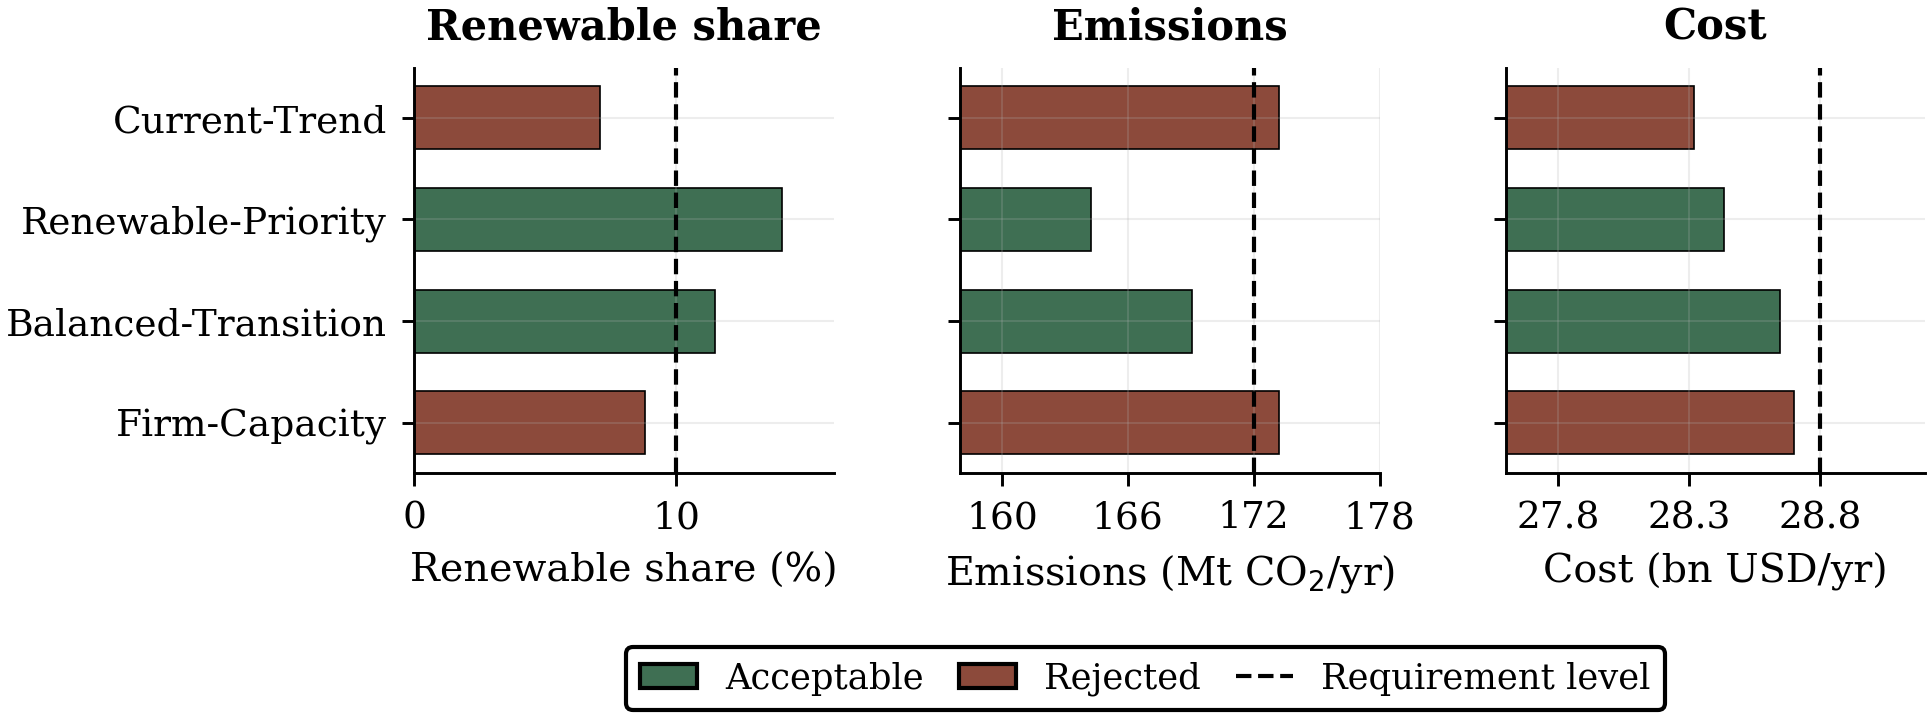

Figure 1. First-stage screening of the four candidate configurations.



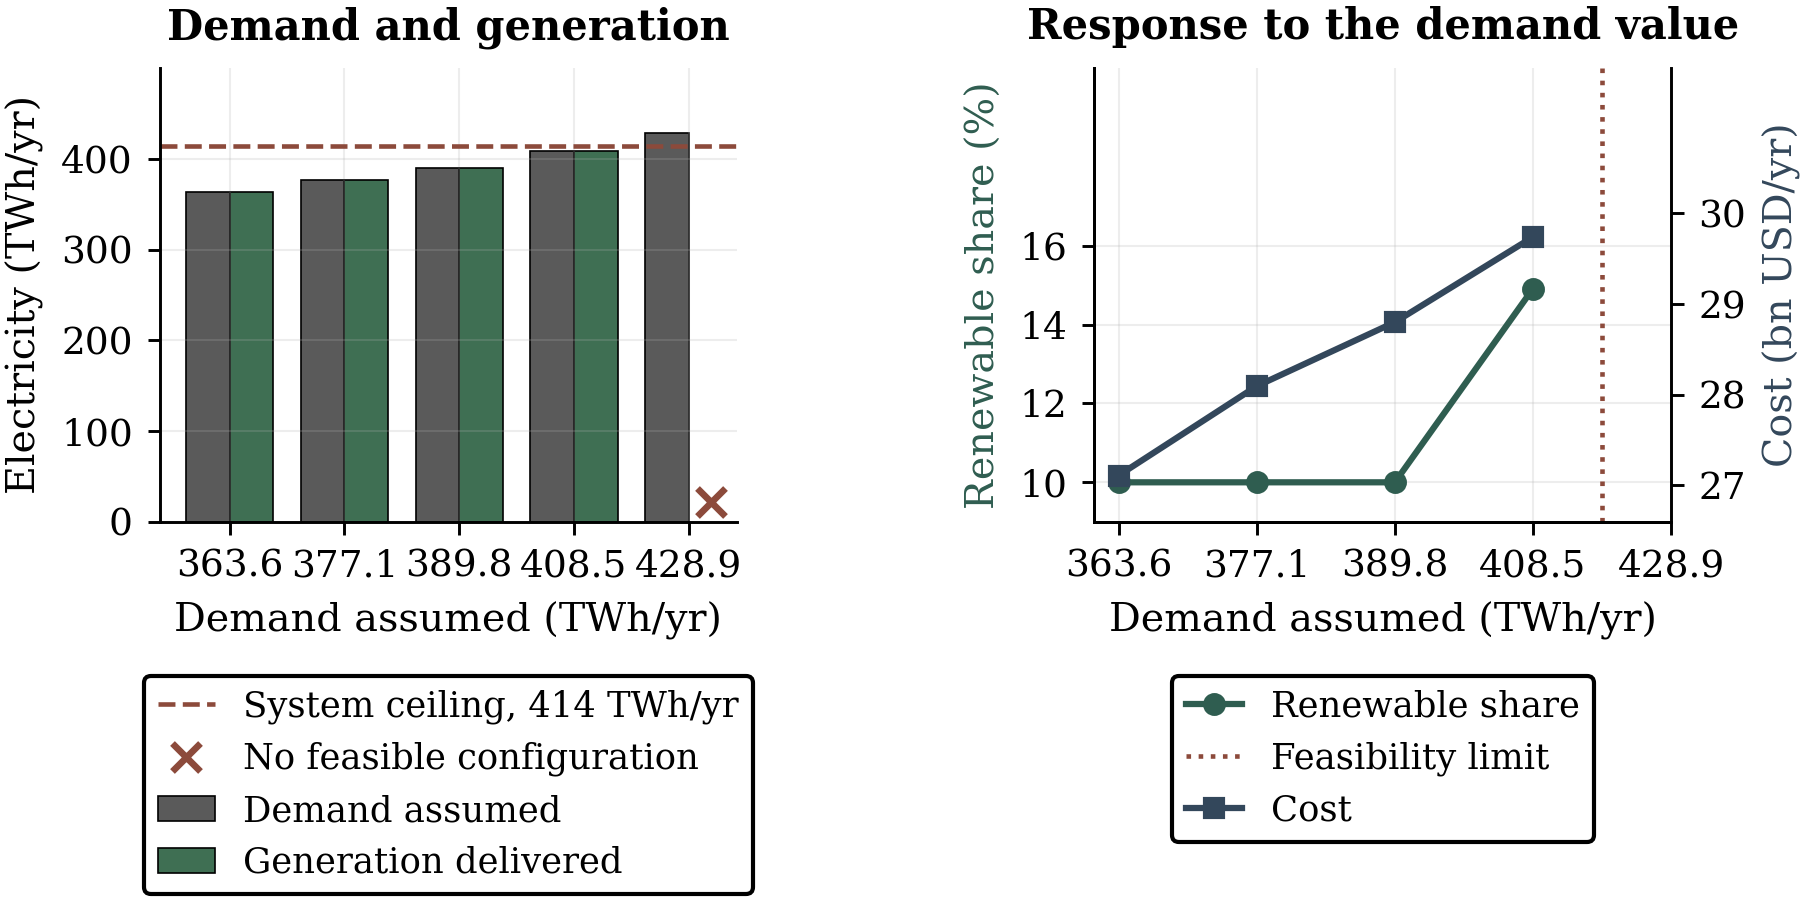

Figure 2. The decision solved at five demand levels, with the feasibility limit.



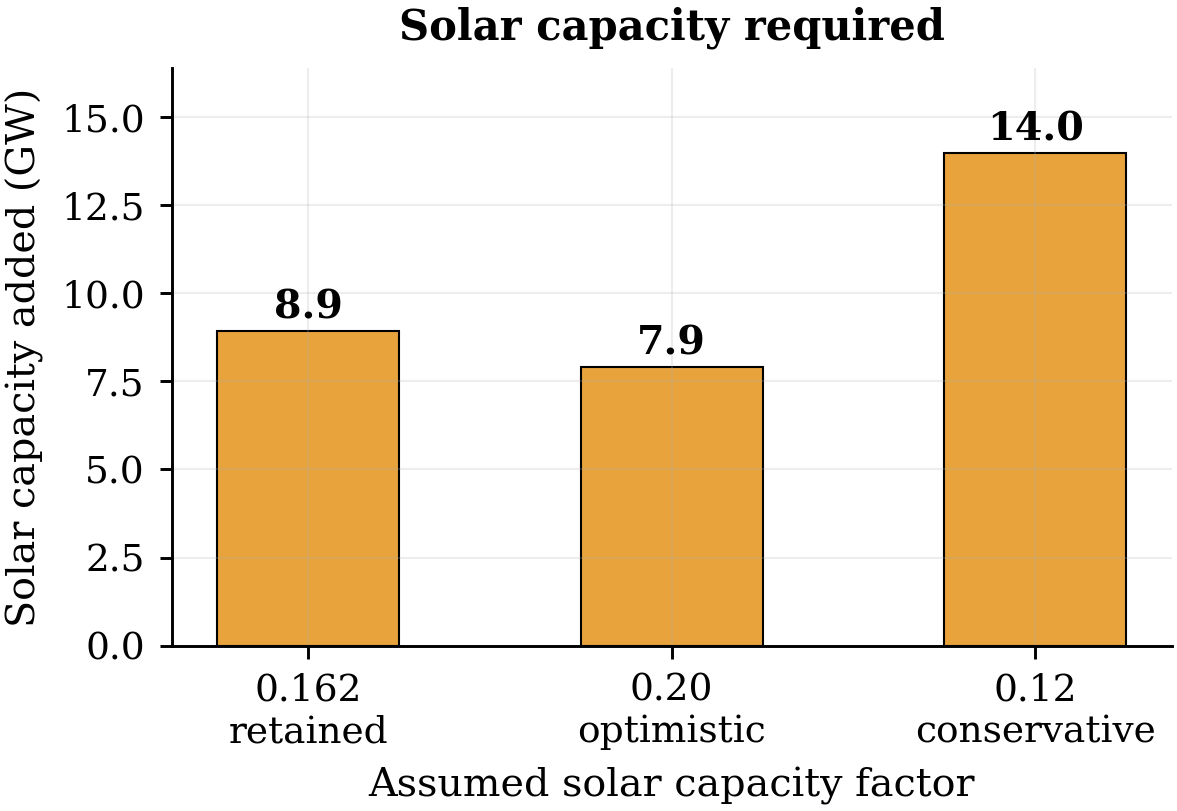

Figure 3. Solar capacity required under three capacity-factor assumptions.



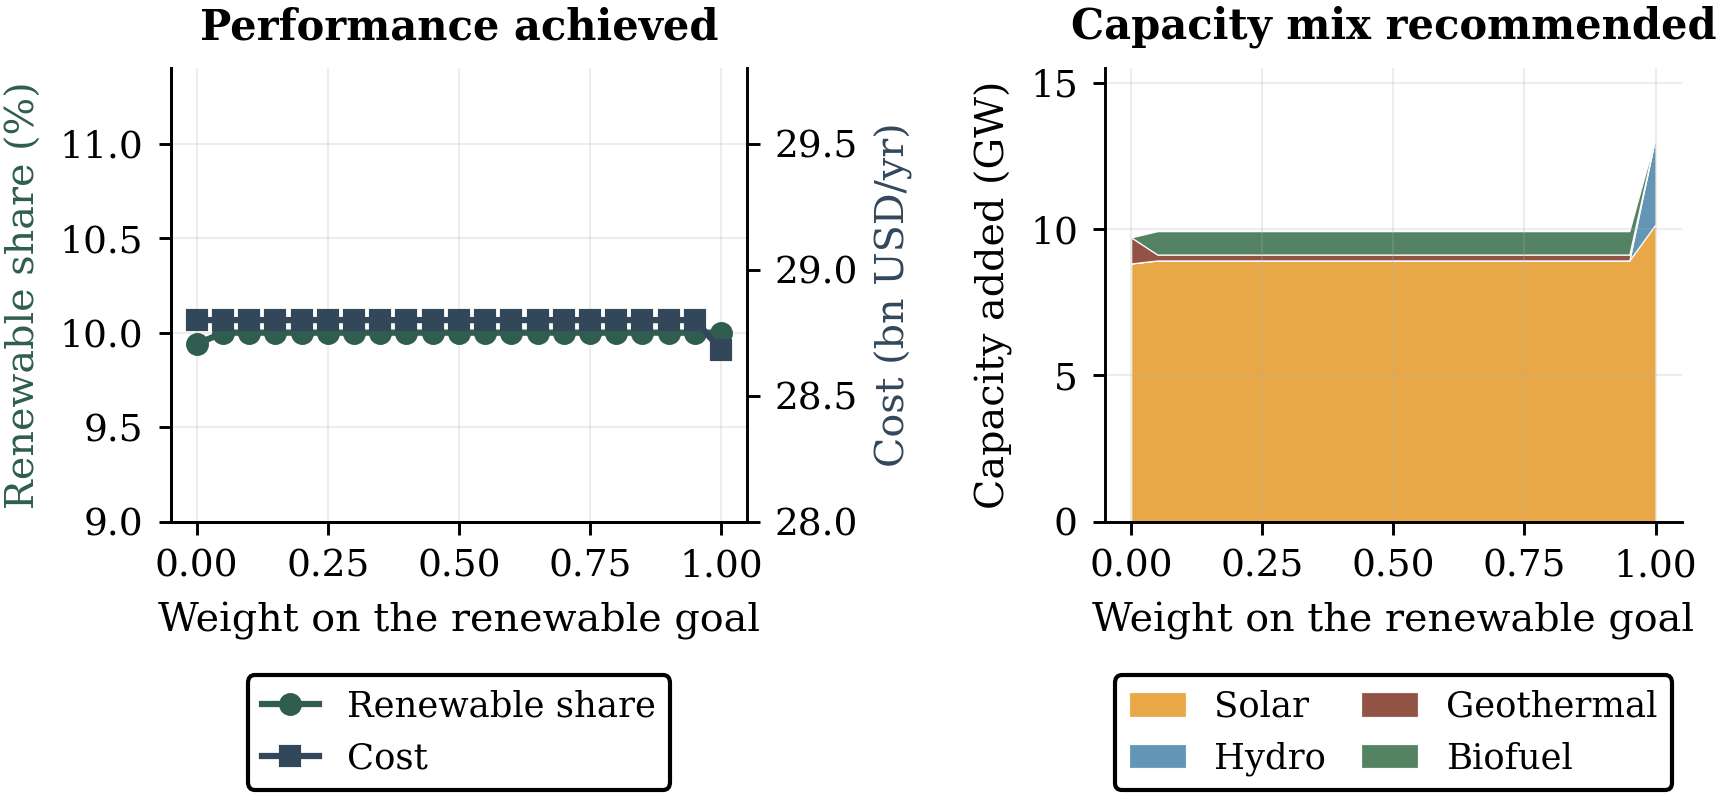

Figure 4. The decision across the range of weight on the renewable-share goal.



In [13]:
import subprocess, sys
subprocess.run([sys.executable, "make_figures.py"], check=True)
from IPython.display import Image, display as disp
for f, cap in [("figs/fig_screening.png", "Figure 1. First-stage screening of the four candidate configurations."),
               ("figs/fig_demand.png",    "Figure 2. The decision solved at five demand levels, with the feasibility limit."),
               ("figs/fig_solar.png",     "Figure 3. Solar capacity required under three capacity-factor assumptions."),
               ("figs/fig_weights.png",   "Figure 4. The decision across the range of weight on the renewable-share goal.")]:
    disp(Image(filename=f)); print(cap); print()

## Closing

We connected forecast-informed quantities, evidence about credibility and model-form
sensitivity, and stakeholder-defined requirements to a configuration decision, and we kept
the path from each source to its effect on the outcome open to inspection. We used the
compromise Decision Support Problem as the formal satisficing construct. Researchers and
designers may apply the same information-mapping principles with other satisficing or
threshold-based approaches that distinguish rigid requirements from desired targets.